In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


In [2]:
df = pd.read_csv("/content/drive/MyDrive/ML_PROJECT/Creditcard_fraud_detection/creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.describe

<bound method NDFrame.describe of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \
0       0.462388  0.239599  0.098698  0.363787  ... -0.018307  0.277838   
1      -0.082361 -0.078803  0.085102 -0.255425  ... -0.225775 -0.638672   
2       1.800499  0.791461  0.247676 -1.514654  ...  0.247998  0.771679   
3       1.247203  0.237609  0.377436 -1.387024  ... -0.108300  0.005274   
4       0.095921  0.592941 -0.270533  0.817739  ... -0.009431  0.798278   
...          ...       ...       ...       ...  ...       ...       ...   
284802 -2.606837 -4.918215  7.305334  1.914428  ...  0.213454  0.111864   
284803  1.058415  0.024330  0.294869  0.584800  ...  0.214205  0.924384   
284804  3.031260 -0.296827  0.708417  0.432454  ...  0.232045  0.578229   
284805  0.623708 -0.686180  0.679145  0.392087  ...  0.265245  0.800049   
284806 -0.649617  1.577006 -0.414650  0.486180  ...  0.261057  0.643078   

             V23       V24       V25       V26       V27       V28  Amount  \
0      -0.110474  0.066928  0.128539 -0.189115  0.133558 -0.021053  149.62   
1       0.101288 -0.339846  0.167170  0.125895 -0.008983  0.014724    2.69   
2       0.909412 -0.689281 -0.327642 -0.139097 -0.055353 -0.059752  378.66   
3      -0.190321 -1.175575  0.647376 -0.221929  0.062723  0.061458  123.50   
4      -0.137458  0.141267 -0.206010  0.502292  0.219422  0.215153   69.99   
...          ...       ...       ...       ...       ...       ...     ...   
284802  1.014480 -0.509348  1.436807  0.250034  0.943651  0.823731    0.77   
284803  0.012463 -1.016226 -0.606624 -0.395255  0.068472 -0.053527   24.79   
284804 -0.037501  0.640134  0.265745 -0.087371  0.004455 -0.026561   67.88   
284805 -0.163298  0.123205 -0.569159  0.546668  0.108821  0.104533   10.00   
284806  0.376777  0.008797 -0.473649 -0.818267 -0.002415  0.013649  217.00   

        Class  
0           0  
1           0  
2           0  
3           0  
4           0  
...       ...  
284802      0  
284803      0  
284804      0  
284805      0  
284806      0  

[284807 rows x 31 columns]>

In [7]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [8]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [9]:
df['Class'].value_counts(normalize = True)*100


,proportion
Class,
0,99.827251
1,0.172749




---



# EDA




In [10]:
df['Amount'].describe()

,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


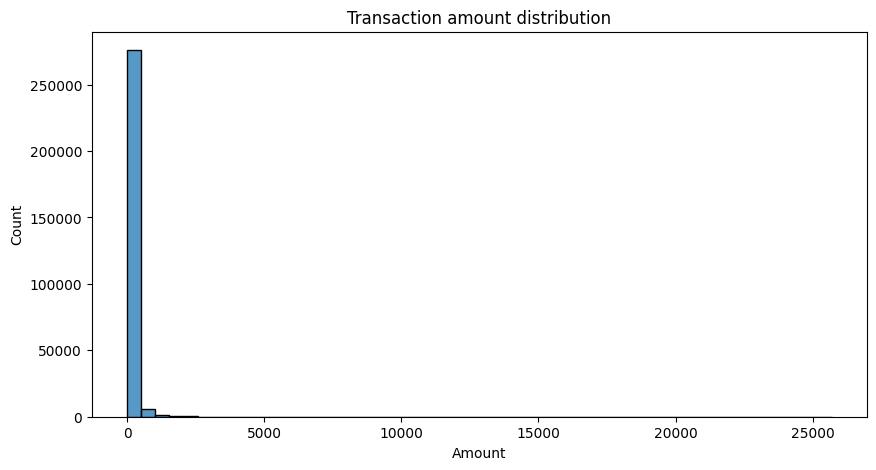

In [11]:
plt.figure(figsize = (10,5))
sns.histplot(df['Amount'] , bins= 50)
plt.title("Transaction amount distribution")
plt.show()

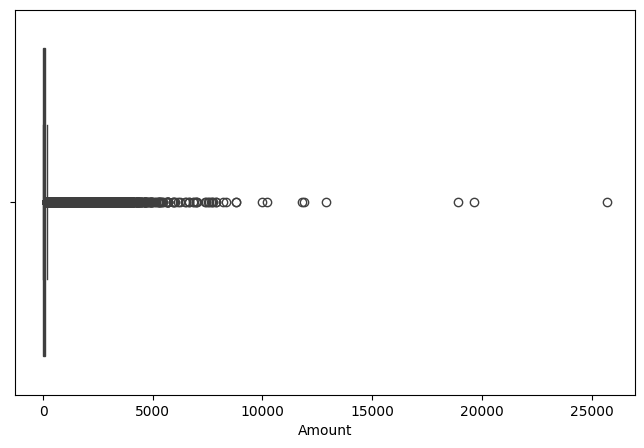

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Amount'])
plt.show()

In [13]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print("Fraud transactions")
print(fraud['Amount'].describe())

print("\nNormal Transaction")
print(normal['Amount'].describe())

Fraud transactions
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Normal Transaction
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


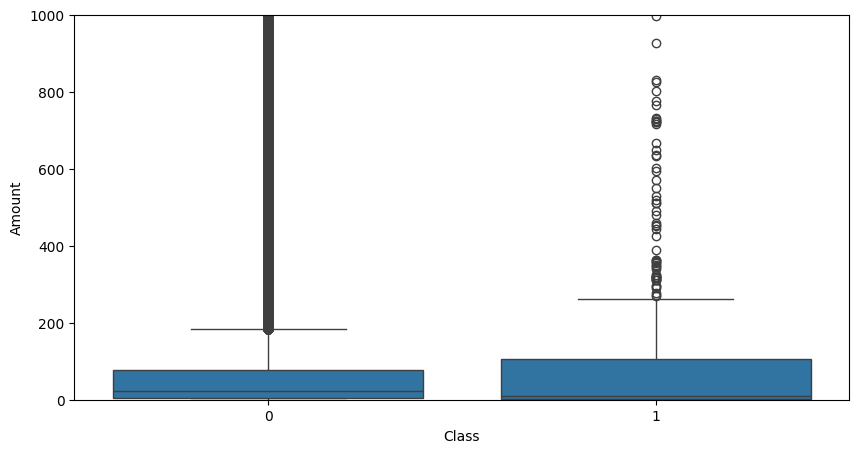

In [14]:
plt.figure(figsize = (10,5))
sns.boxplot(x = 'Class' , y='Amount' , data=df)
plt.ylim(0,1000)
plt.show()

Why limit 1000?

Maximum amount:

25691

Without limit graph useless ho jayega.

# fraud percentage visually

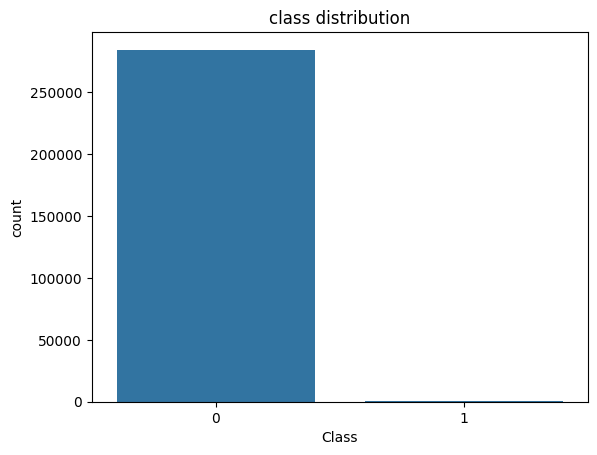

In [15]:
sns.countplot(x = 'Class' , data = df)
plt.title("class distribution")
plt.show()

In [16]:
df['Class'].value_counts(normalize=True)*100

,proportion
Class,
0,99.827251
1,0.172749


In [17]:
X = df.drop('Class' , axis = 1)
y = df['Class']

In [18]:
X.shape

(284807, 30)

In [19]:
y.shape

(284807,)



---



---



# Train-test split

In [20]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y, test_size = 0.2 , random_state = 42 , stratify = y)

In [21]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(227845, 30)
(56962, 30)
(227845,)
(56962,)


**checking fraud distribution**

In [22]:
y_train.value_counts()
y_test.value_counts()

,count
Class,
0,56864
1,98


# Model selection and prediction

In [23]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train , y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [24]:
y_pred = lr.predict(X_test)

**evaluation metrics**

In [25]:
from sklearn.metrics import accuracy_score ,classification_report, confusion_matrix

accuracy_score(y_test , y_pred)

0.9992451107756047

In [26]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.69      0.76        98

    accuracy                           1.00     56962
   macro avg       0.92      0.85      0.88     56962
weighted avg       1.00      1.00      1.00     56962



In [27]:
print(confusion_matrix(y_test , y_pred))

[[56851    13]
 [   30    68]]


**now we will fix the imbalanced data using SMOTE**

In [28]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)

X_train_smote , y_train_smote = smote.fit_resample(X_train , y_train)

# before
print("before smote",y_train.value_counts())

print("after smote",y_train_smote.value_counts())

before smote Class
0    227451
1       394
Name: count, dtype: int64
after smote Class
0    227451
1    227451
Name: count, dtype: int64


In [29]:
from sklearn.linear_model import LogisticRegression
lr_smote = LogisticRegression(max_iter=1000)
lr_smote.fit(X_train_smote , y_train_smote)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [30]:
y_pred_smote = lr_smote.predict(X_test)

# Evaluation

In [31]:
from sklearn.metrics import accuracy_score ,classification_report, confusion_matrix

print("Accuracy\n:")
print(accuracy_score(y_test , y_pred_smote))

print("\nClassification Report\n:")
print(classification_report(y_test , y_pred_smote))

print("\nConfusion Matrix\n:")
print(confusion_matrix(y_test , y_pred_smote))

Accuracy
:
0.9883957726203434

Classification Report
:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.90      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962


Confusion Matrix
:
[[56213   651]
 [   10    88]]


**Next step: Threshold Tuning, because it will tell how banks actually decide when to flag a transaction as fraud.**

In [32]:
y_prob = lr_smote.predict_proba(X_test)[:,1]

In [33]:
y_pred_50 = (y_prob>=0.50).astype(int)

y_pred_30 = (y_prob>=0.30).astype(int)

y_pred_70 = (y_prob>=0.70).astype(int)

In [34]:
from sklearn.metrics import precision_score , recall_score , f1_score

for t,pred in [
    ("0.30",y_pred_30),
    ("0.50",y_pred_50),
    ("0.70",y_pred_70)]:

    print(f"Threshold =  {t}")

    print("Precision" , precision_score(y_test , pred))
    print("Recall" , recall_score(y_test , pred))
    print("F1 Score" , f1_score(y_test , pred))




Threshold =  0.30
Precision 0.06290207290922087
Recall 0.8979591836734694
F1 Score 0.11756847027388109
Threshold =  0.50
Precision 0.11907983761840325
Recall 0.8979591836734694
F1 Score 0.21027479091995221
Threshold =  0.70
Precision 0.18683651804670912
Recall 0.8979591836734694
F1 Score 0.3093145869947276


ROC-AUC Score: 0.9759745414766919


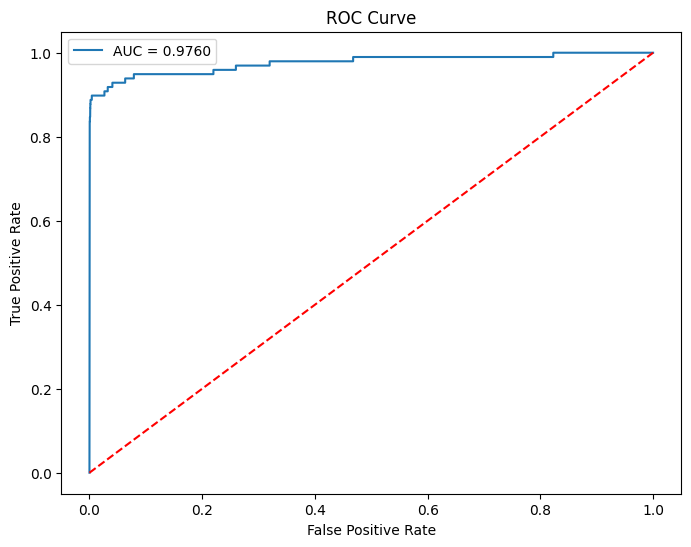

In [35]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = lr_smote.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Baseline Logistic Regression**       
↓
**69%** Recall   

**SMOTE + Logistic Regression**      
↓
**90%** Recall     

In [36]:
import joblib

joblib.dump(lr_smote, "fraud_model.pkl")

['fraud_model.pkl']